        name  study_hours  sleep_hours  attendance_pct  score passed
0  Student_1          4.4          8.8            89.3   66.3    Yes
1  Student_2          2.4          5.2            94.6   58.1    Yes
2  Student_3          6.4          7.8            60.8   74.0    Yes
3  Student_4          2.7          6.2            81.0   51.4    Yes
4  Student_5          4.9          6.2            84.5   68.6    Yes
(50, 6)
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            50 non-null     str    
 1   study_hours     50 non-null     float64
 2   sleep_hours     50 non-null     float64
 3   attendance_pct  50 non-null     float64
 4   score           50 non-null     float64
 5   passed          50 non-null     str    
dtypes: float64(4), str(2)
memory usage: 2.5 KB
None
name                  str
study_hours       float64
sleep_hours       floa

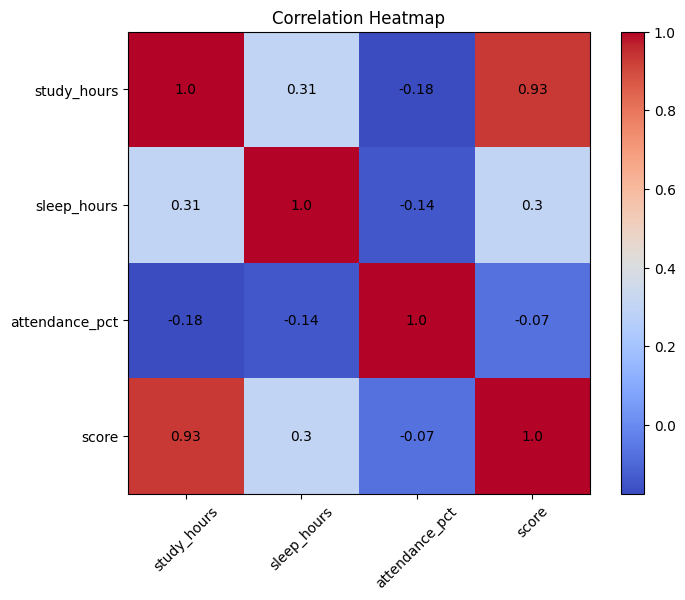

Top 3 Strongest Correlations
study_hours  score          0.932485
             sleep_hours    0.306025
sleep_hours  score          0.301990
dtype: float64
Top 3 Weakest Correlations
study_hours     attendance_pct    0.175232
sleep_hours     attendance_pct    0.141304
attendance_pct  score             0.073379
dtype: float64


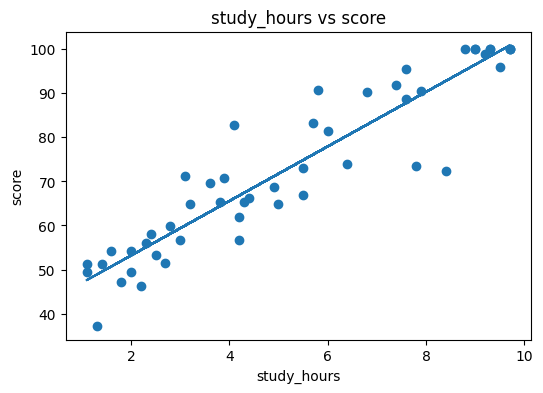

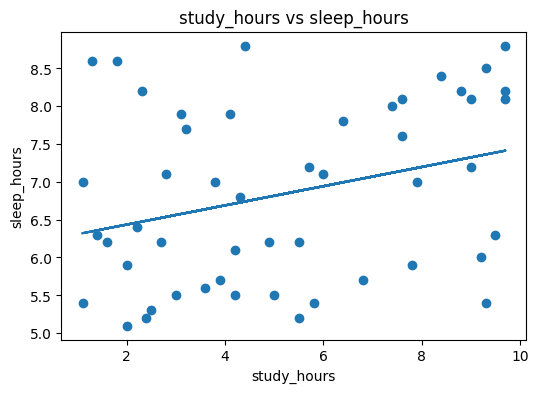

1. Study hours and score have strong positive correlation.
2. Higher attendance generally improves scores.
3. More study does not always guarantee higher score.
4. Sleep hours have weaker relationship with score.
5. Random noise creates realistic variation in results.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

students = []

for i in range(50):

    name = f"Student_{i+1}"
    study_hours = round(np.random.uniform(1, 10), 1)
    sleep_hours = round(np.random.uniform(5, 9), 1)
    attendance_pct = round(np.random.uniform(60, 100), 1)
    noise = np.random.normal(0, 8)
    score = (
        study_hours * 7 +
        attendance_pct * 0.3 +
        sleep_hours * 2 +
        noise
    )

    score = round(max(0, min(score, 100)), 1)

    passed = "Yes" if score >= 40 else "No"

    students.append([
        name,
        study_hours,
        sleep_hours,
        attendance_pct,
        score,
        passed
    ])

df = pd.DataFrame(
    students,
    columns=[
        "name",
        "study_hours",
        "sleep_hours",
        "attendance_pct",
        "score",
        "passed"
    ]
)

df.to_csv("student_dataset.csv", index=False)

print(df.head())
print(df.shape)
print(df.info())
print(df.dtypes)
print(df.isnull().sum())
print((df.isnull().sum() / len(df)) * 100)
print(df.describe())
print(df["passed"].value_counts())

correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)
plt.figure(figsize=(8,6))
plt.imshow(correlation_matrix, cmap="coolwarm")
plt.colorbar()
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            round(correlation_matrix.iloc[i, j], 2),
            ha="center",
            va="center",
            color="black"
        )

plt.title("Correlation Heatmap")
plt.show()

corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs.drop_duplicates()
corr_pairs = corr_pairs[corr_pairs != 1]
sorted_corr = corr_pairs.abs().sort_values(ascending=False)

print("Top 3 Strongest Correlations")
print(sorted_corr.head(3))
print("Top 3 Weakest Correlations")
print(sorted_corr.tail(3))

top_pairs = sorted_corr.head(2).index

for x_col, y_col in top_pairs:

    plt.figure(figsize=(6,4))
    x = df[x_col]
    y = df[y_col]
    plt.scatter(x, y)
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")
    plt.show()

print("1. Study hours and score have strong positive correlation.")
print("2. Higher attendance generally improves scores.")
print("3. More study does not always guarantee higher score.")
print("4. Sleep hours have weaker relationship with score.")
print("5. Random noise creates realistic variation in results.")